# Part 2: Preprocessing and Clustering of PBMC scRNA-seq Data

## Overview
This notebook performs preprocessing and clustering analysis on **Peripheral Blood Mononuclear Cells (PBMCs)** data that was preprocessed in Part 1 using Galaxy/STARsolo and DropletUtils.

### Data Origin
- **Source**: 1k PBMCs from a Healthy Donor (10X Genomics, v3 chemistry)
- **Genome**: Human hg19 chromosome X (chrX)
- **Preprocessing**: RNA STARsolo → DropletUtils (EmptyDrops filtering)
- **Cells**: 252 high-quality cells
- **Genes**: 2,392 genes (chrX genes only)

### Pipeline
```
Part 1 Output (barcodes.tsv + genes.tsv + matrix.mtx)
        ↓
Load into AnnData object
        ↓
Quality Control
        ↓
Doublet Detection
        ↓
Normalization
        ↓
Feature Selection
        ↓
Dimensionality Reduction (PCA → UMAP)
        ↓
Clustering (Leiden)
        ↓
Cell Type Annotation
        ↓
Save as .h5ad → Input for Part 3
```

### References
- Tutorial: [scverse Preprocessing and Clustering](https://scverse-tutorials.readthedocs.io/en/latest/notebooks/clustering.html)
- Luecken et al. 2021 (NeurIPS benchmarking dataset)


## Step 0: Install Required Packages

Run this cell only once. If running on Google Colab, restart the runtime after installation.

In [1]:
!pip install scanpy anndata seaborn igraph leidenalg scrublet -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 14.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 81.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages tha

## Step 1: Import Libraries

In [2]:
from __future__ import annotations

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad

# Settings
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(6, 6))
sc.settings.verbosity = 3

print('Scanpy version:', sc.__version__)
print('AnnData version:', ad.__version__)
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)

Scanpy version: 1.12.1
AnnData version: 0.12.10
NumPy version: 2.0.2
Pandas version: 2.3.3


## Step 2: Upload Data Files

Upload the 3 output files from Part 1 (Galaxy/DropletUtils):
- `barcodes.tsv` — cell barcodes
- `genes.tsv` — gene IDs and names
- `matrix.mtx` — count matrix

**If running on Google Colab**, run the cell below to upload files interactively.

In [3]:
# Upload files (Google Colab only)
# Skip this cell if running locally and files are already in the same folder

try:
    from google.colab import files
    import os
    os.makedirs('data', exist_ok=True)
    print('Please upload your 3 files: barcodes.tsv, genes.tsv, matrix.mtx')
    uploaded = files.upload()
    for filename, content in uploaded.items():
        with open(f'data/{filename}', 'wb') as f:
            f.write(content)
    print('Files uploaded successfully!')
except ImportError:
    print('Not running on Colab. Make sure files are in the data/ folder.')

Please upload your 3 files: barcodes.tsv, genes.tsv, matrix.mtx


Saving Galaxy38-[DropletUtils 10X Barcodes on dataset 27-29].tsv to Galaxy38-[DropletUtils 10X Barcodes on dataset 27-29].tsv
Saving Galaxy39-[DropletUtils 10X Genes on dataset 27-29].tsv to Galaxy39-[DropletUtils 10X Genes on dataset 27-29].tsv
Saving Galaxy40-[DropletUtils 10X Matrices on dataset 27-29].mtx to Galaxy40-[DropletUtils 10X Matrices on dataset 27-29].mtx
Files uploaded successfully!


## Step 3: Load Data into AnnData Object

We load the 10X MTX format output from Part 1 into an **AnnData** object — the standard data structure for single-cell analysis in Python.

The genes file has two columns: Ensembl ID and gene name. We will use gene names as the primary identifier.

In [4]:
import scipy.io
from scipy.sparse import csr_matrix
import os

# Define file paths
# Update these filenames if your files have different names
data_dir = 'data'

# Find the uploaded files automatically
files_in_dir = os.listdir(data_dir)
print('Files found in data/ directory:', files_in_dir)

# Identify each file
barcode_file = [f for f in files_in_dir if 'Barcode' in f or 'barcode' in f or f == 'barcodes.tsv'][0]
gene_file = [f for f in files_in_dir if 'Gene' in f or 'gene' in f or 'feature' in f or f == 'genes.tsv'][0]
matrix_file = [f for f in files_in_dir if '.mtx' in f][0]

print(f'\nBarcode file: {barcode_file}')
print(f'Gene file:    {gene_file}')
print(f'Matrix file:  {matrix_file}')

Files found in data/ directory: ['Galaxy38-[DropletUtils 10X Barcodes on dataset 27-29].tsv', 'Galaxy40-[DropletUtils 10X Matrices on dataset 27-29].mtx', 'Galaxy39-[DropletUtils 10X Genes on dataset 27-29].tsv']

Barcode file: Galaxy38-[DropletUtils 10X Barcodes on dataset 27-29].tsv
Gene file:    Galaxy39-[DropletUtils 10X Genes on dataset 27-29].tsv
Matrix file:  Galaxy40-[DropletUtils 10X Matrices on dataset 27-29].mtx


In [5]:
# Load matrix
matrix = scipy.io.mmread(os.path.join(data_dir, matrix_file)).T
matrix = csr_matrix(matrix)

# Load barcodes
barcodes = pd.read_csv(os.path.join(data_dir, barcode_file),
                        header=None, sep='\t')[0].tolist()

# Load genes (two columns: Ensembl ID and gene name)
genes = pd.read_csv(os.path.join(data_dir, gene_file),
                     header=None, sep='\t')
gene_ids = genes[0].tolist()      # Ensembl IDs
gene_names = genes[1].tolist()    # Gene names

# Create AnnData object
adata = ad.AnnData(
    X=matrix,
    obs=pd.DataFrame(index=barcodes),
    var=pd.DataFrame({'gene_ids': gene_ids, 'gene_names': gene_names},
                      index=gene_names)
)

# Make variable names unique
adata.var_names_make_unique()

print('AnnData object created successfully!')
print(adata)

AnnData object created successfully!
AnnData object with n_obs × n_vars = 252 × 2392
    var: 'gene_ids', 'gene_names'


In [6]:
# Summary of loaded data
print(f'Number of cells:  {adata.n_obs}')
print(f'Number of genes:  {adata.n_vars}')
print(f'\nFirst 5 cell barcodes:')
print(adata.obs_names[:5].tolist())
print(f'\nFirst 5 gene names:')
print(adata.var_names[:5].tolist())
print(f'\nData matrix type: {type(adata.X)}')
print(f'Data matrix shape: {adata.X.shape}')

Number of cells:  252
Number of genes:  2392

First 5 cell barcodes:
['AAAGAACCAATGGCAG', 'AAAGGATAGTAGACAT', 'AAAGGATCACCGGCTA', 'AAAGGATTCCGTTTCG', 'AAAGTCCCACCAGCCA']

First 5 gene names:
['LL0YNC03-29C1.1', 'PLCXD1', 'GTPBP6', 'LINC00685', 'PPP2R3B']

Data matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Data matrix shape: (252, 2392)


## Step 4: Quality Control

Quality control (QC) is essential to remove low-quality cells before analysis. We calculate common QC metrics:

- **n_genes_by_counts**: Number of genes detected per cell
- **total_counts**: Total UMI counts per cell
- **pct_counts_ribo**: Percentage of ribosomal gene counts

> **Note**: This dataset is from chromosome X only (hg19 chrX), so there are **no mitochondrial genes** (MT genes are on the mitochondrial chromosome). We use ribosomal genes as an alternative QC metric.

In [7]:
# Annotate ribosomal genes (RPL and RPS prefixes)
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))

print(f"Number of ribosomal genes: {adata.var['ribo'].sum()}")
print(f"Ribosomal genes found: {adata.var_names[adata.var['ribo']].tolist()[:10]}...")

Number of ribosomal genes: 54
Ribosomal genes found: ['RPL14P5', 'RPL17P49', 'RPL30P15', 'RPL6P30', 'RPS6KA3', 'RPL9P7', 'RPL7P58', 'RPS15AP40', 'RPS11P7', 'RPS2P55']...


In [8]:
# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['ribo'],
    inplace=True,
    log1p=True
)

print('QC metrics calculated!')
print('\nQC columns added to adata.obs:')
print(adata.obs.columns.tolist())

QC metrics calculated!

QC columns added to adata.obs:
['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo']


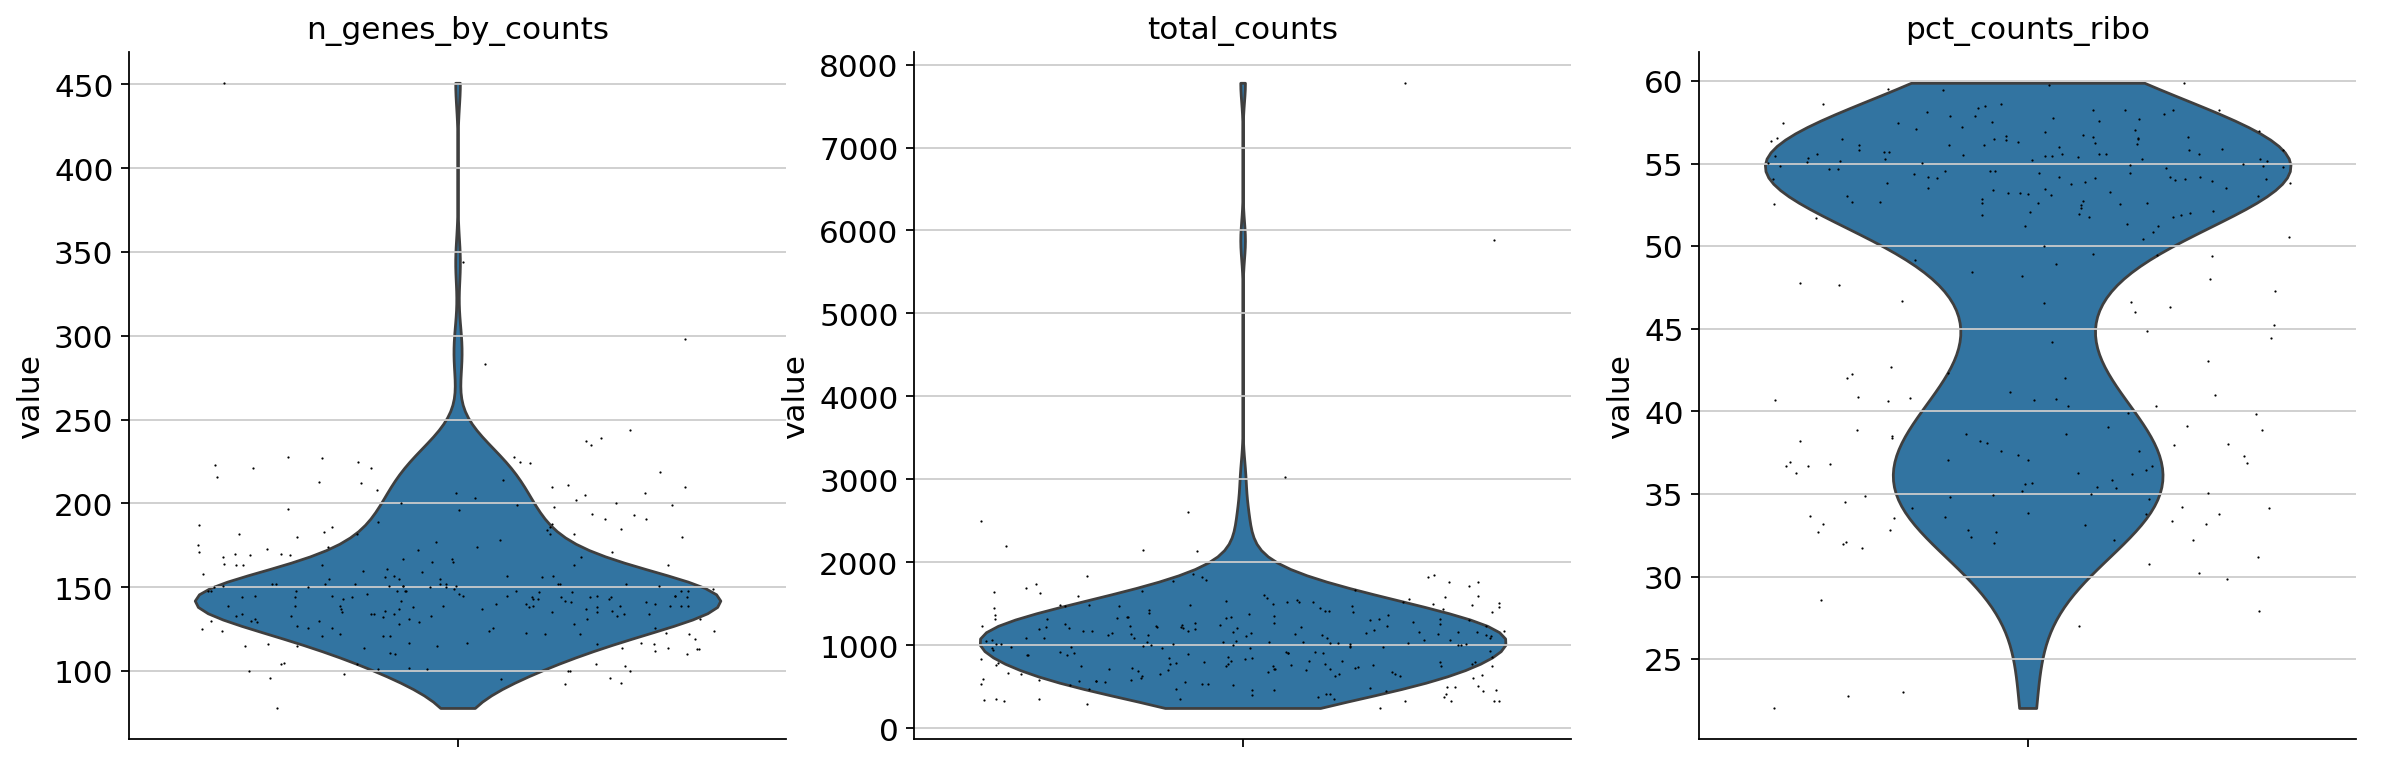

In [9]:
# Violin plots of QC metrics
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_ribo'],
    jitter=0.4,
    multi_panel=True
)

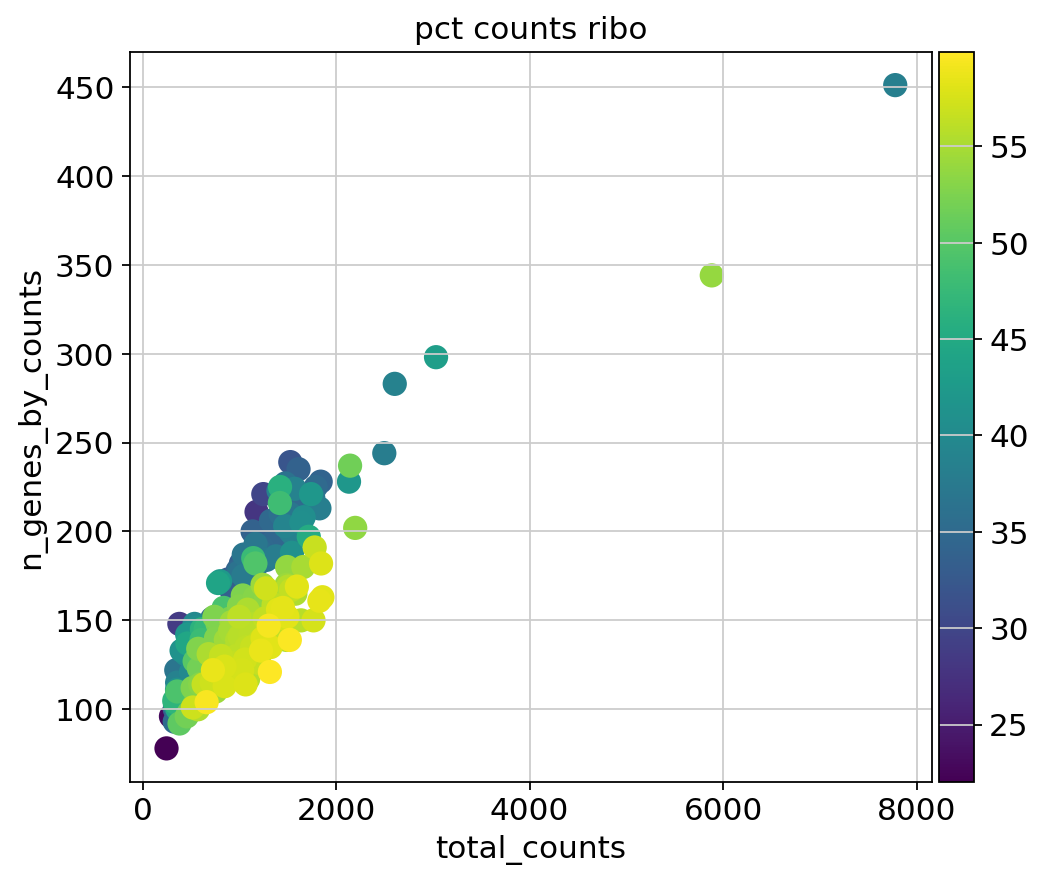

In [10]:
# Scatter plot: total counts vs genes detected, colored by ribosomal %
sc.pl.scatter(
    adata,
    x='total_counts',
    y='n_genes_by_counts',
    color='pct_counts_ribo'
)

In [11]:
# Print summary statistics
print('=== QC Summary Statistics ===')
print(f"Total cells before filtering: {adata.n_obs}")
print(f"\nGenes per cell:")
print(f"  Min:    {adata.obs['n_genes_by_counts'].min():.0f}")
print(f"  Median: {adata.obs['n_genes_by_counts'].median():.0f}")
print(f"  Max:    {adata.obs['n_genes_by_counts'].max():.0f}")
print(f"\nTotal counts per cell:")
print(f"  Min:    {adata.obs['total_counts'].min():.0f}")
print(f"  Median: {adata.obs['total_counts'].median():.0f}")
print(f"  Max:    {adata.obs['total_counts'].max():.0f}")

=== QC Summary Statistics ===
Total cells before filtering: 252

Genes per cell:
  Min:    78
  Median: 146
  Max:    451

Total counts per cell:
  Min:    245
  Median: 1039
  Max:    7780


In [12]:
# Filter cells and genes with permissive thresholds
# (following tutorial recommendation: start permissive, revisit later)
print(f'Cells before filtering: {adata.n_obs}')
print(f'Genes before filtering: {adata.n_vars}')

sc.pp.filter_cells(adata, min_genes=50)
sc.pp.filter_genes(adata, min_cells=3)

print(f'\nCells after filtering: {adata.n_obs}')
print(f'Genes after filtering: {adata.n_vars}')

Cells before filtering: 252
Genes before filtering: 2392
filtered out 1641 genes that are detected in less than 3 cells

Cells after filtering: 252
Genes after filtering: 751


## Step 5: Doublet Detection

Doublets are droplets that accidentally captured two cells instead of one. They appear as cells with unusually high gene counts and can distort downstream analysis. We use **Scrublet** to detect and flag them.

In [13]:
# Run Scrublet doublet detection
sc.pp.scrublet(adata)

print('Doublet detection complete!')
print(f"Predicted doublets: {adata.obs['predicted_doublet'].sum()}")
print(f"Singlets (real cells): {(~adata.obs['predicted_doublet']).sum()}")

Running Scrublet
normalizing counts per cell
    finished (0:00:04)
extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.15
Detected doublet rate = 4.0%
Estimated detectable doublet fraction = 11.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 35.7%
    Scrublet finished (0:00:10)
Doublet detection complete!
Predicted doublets: 10
Singlets (real cells): 242


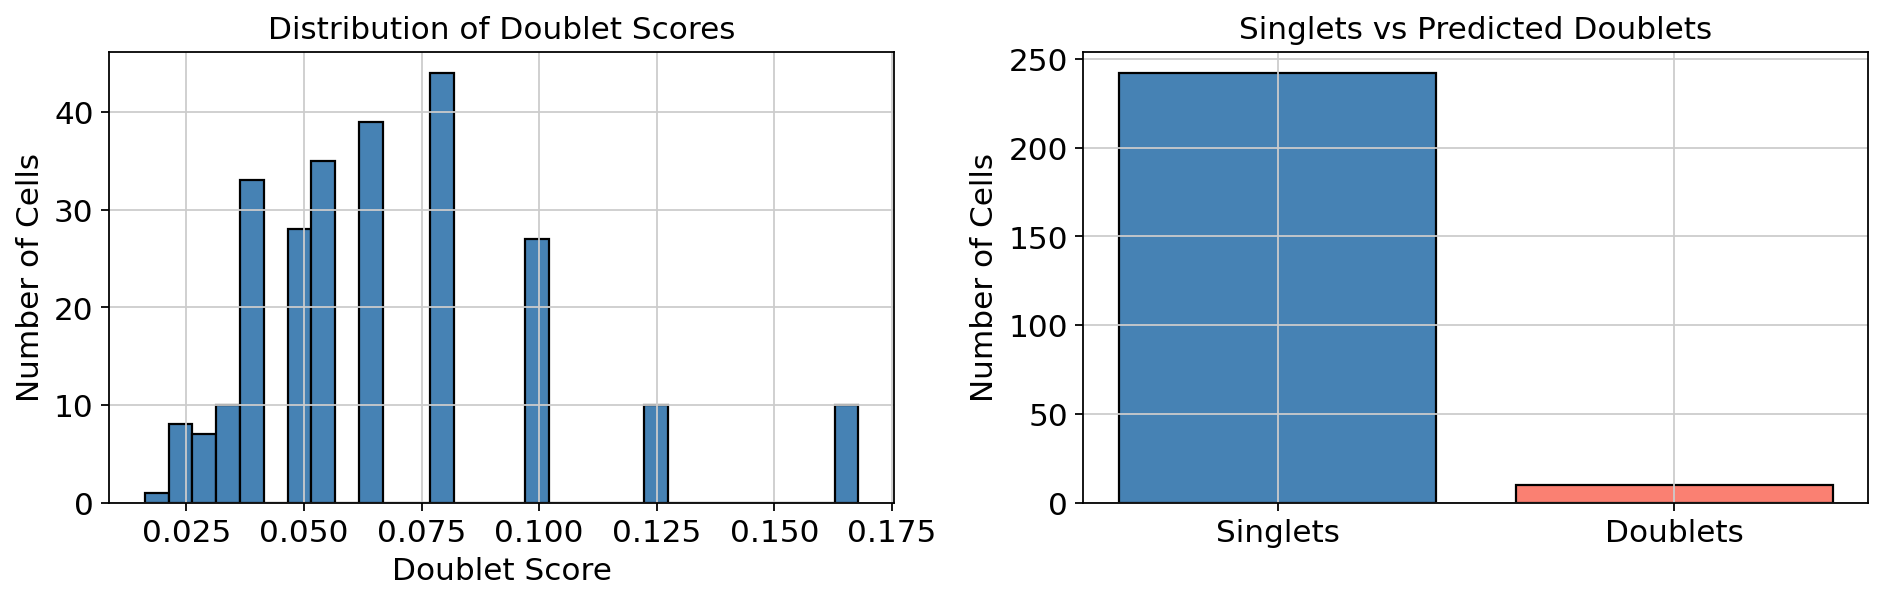

Plot saved as doublet_detection.png


In [14]:
# Visualize doublet scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Doublet score distribution
axes[0].hist(adata.obs['doublet_score'], bins=30, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Doublet Score')
axes[0].set_ylabel('Number of Cells')
axes[0].set_title('Distribution of Doublet Scores')

# Doublet vs singlet counts
doublet_counts = adata.obs['predicted_doublet'].value_counts()
axes[1].bar(['Singlets', 'Doublets'],
             [doublet_counts.get(False, 0), doublet_counts.get(True, 0)],
             color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_ylabel('Number of Cells')
axes[1].set_title('Singlets vs Predicted Doublets')

plt.tight_layout()
plt.savefig('doublet_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as doublet_detection.png')

## Step 6: Normalization

We normalize the data using **count depth scaling** followed by **log1p transformation**:

1. Save raw counts in a separate layer for future reference
2. Normalize each cell to the median total count depth
3. Apply log(1+x) transformation to stabilize variance

In [15]:
# Save raw counts before normalization
adata.layers['counts'] = adata.X.copy()
print('Raw counts saved in adata.layers["counts"]')

# Normalize to median total counts
sc.pp.normalize_total(adata)
print('Normalization complete!')

# Log1p transformation
sc.pp.log1p(adata)
print('Log1p transformation complete!')

# Save normalized data in a layer too
adata.layers['log_normalized'] = adata.X.copy()

print('\nCurrent AnnData object:')
print(adata)

Raw counts saved in adata.layers["counts"]
normalizing counts per cell
    finished (0:00:00)
Normalization complete!
Log1p transformation complete!

Current AnnData object:
AnnData object with n_obs × n_vars = 252 × 751
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'gene_names', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'counts', 'log_normalized'


## Step 7: Feature Selection (Highly Variable Genes)

We select the most **highly variable genes (HVGs)** — genes that show high variability across cells. These are the most informative genes for distinguishing cell types.

Since our dataset only has 2,392 genes (chrX only), we use a smaller number of top genes.

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Number of highly variable genes: 500


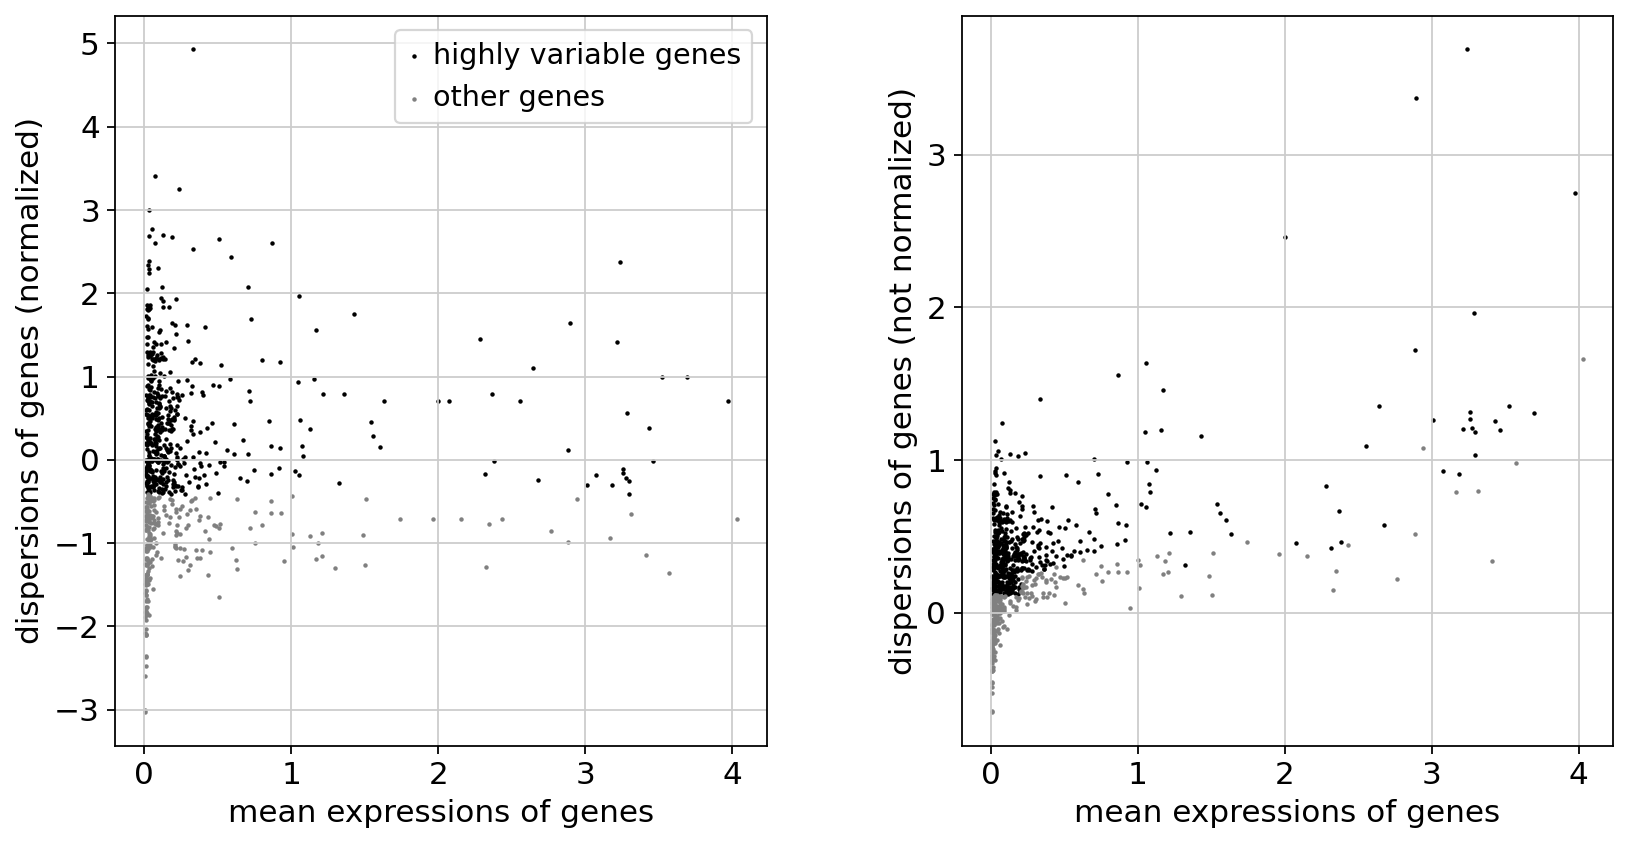

In [16]:
# Select highly variable genes
# Using min_mean and max_mean thresholds suitable for chrX dataset size
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=500,   # Use 500 top HVGs (dataset is small - chrX only)
    flavor='seurat'
)

print(f"Number of highly variable genes: {adata.var['highly_variable'].sum()}")

# Plot HVG selection
sc.pl.highly_variable_genes(adata)

In [17]:
# Show top 20 highly variable genes
hvg_df = adata.var[adata.var['highly_variable']].sort_values('dispersions_norm', ascending=False)
print('Top 20 Highly Variable Genes:')
print(hvg_df.head(20)[['gene_ids', 'means', 'dispersions_norm']])

Top 20 Highly Variable Genes:
                         gene_ids     means  dispersions_norm
TSPYL2            ENSG00000184205  0.332938          4.930963
IL3RA             ENSG00000185291  0.075465          3.407915
SH2D1A            ENSG00000183918  0.233641          3.253045
LINC00892         ENSG00000233093  0.030216          3.001204
RNU2-68P          ENSG00000222810  0.050474          2.773499
HCCS              ENSG00000004961  0.128203          2.701683
CSTF2             ENSG00000101811  0.032587          2.689840
FAM58A            ENSG00000147382  0.188292          2.669911
CFP               ENSG00000126759  0.510592          2.654906
CYBB              ENSG00000165168  0.867137          2.607136
BCOR              ENSG00000183337  0.070477          2.600706
ITM2A             ENSG00000078596  0.331782          2.531744
TIMP1             ENSG00000102265  0.590564          2.433437
MAP2K4P1          ENSG00000269904  0.032858          2.389904
FTLP2             ENSG00000232368  3.238

## Step 8: Dimensionality Reduction

We reduce the dimensionality of the dataset using:
1. **PCA** (Principal Component Analysis) — linear reduction
2. **UMAP** — non-linear reduction for visualization

PCA is applied only on the highly variable genes.

In [18]:
# Run PCA on highly variable genes
sc.tl.pca(adata, use_highly_variable=True)

print('PCA complete!')
print(f'PCA shape: {adata.obsm["X_pca"].shape}')

computing PCA
    with n_comps=50
    finished (0:00:00)
PCA complete!
PCA shape: (252, 50)


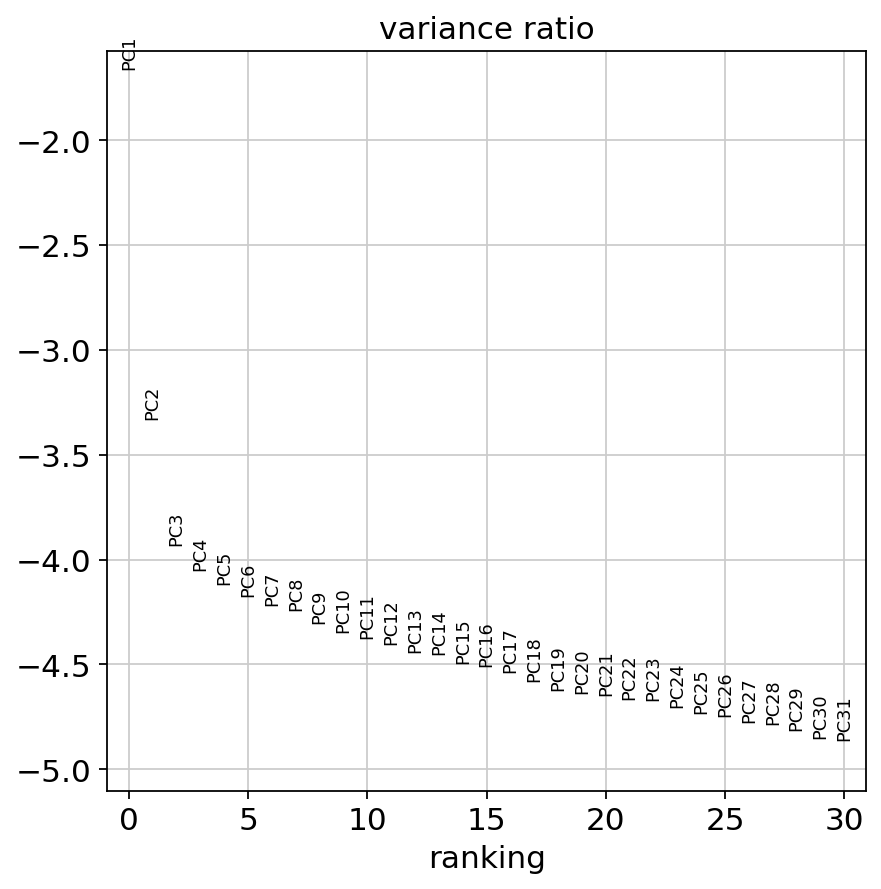

In [19]:
# Plot PCA variance ratio to choose number of PCs
sc.pl.pca_variance_ratio(adata, n_pcs=30, log=True)

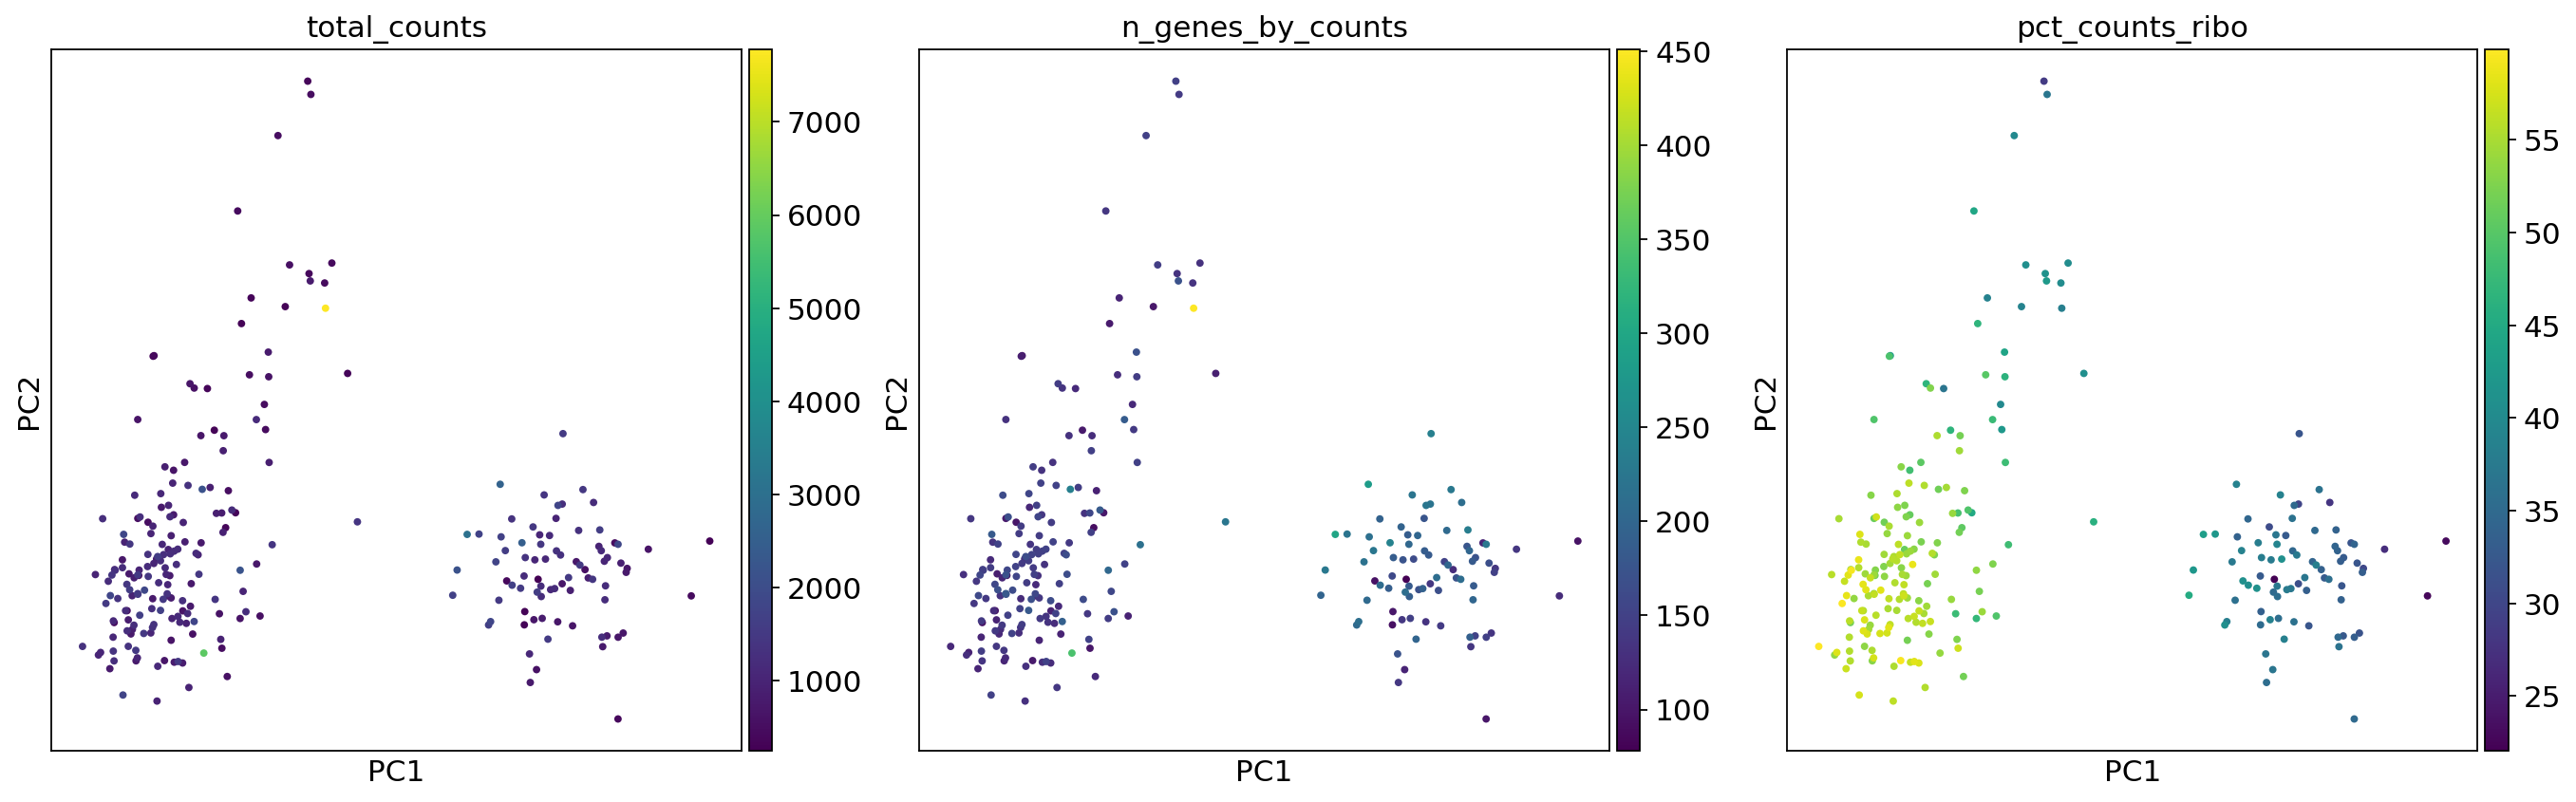

In [20]:
# Plot PCA colored by QC metrics to check for unwanted variation
sc.pl.pca(
    adata,
    color=['total_counts', 'n_genes_by_counts', 'pct_counts_ribo'],
    ncols=3,
    size=50
)

## Step 9: Nearest Neighbor Graph and UMAP

We build a **k-nearest neighbor graph** using the PCA representation, then embed it in 2D using **UMAP** for visualization.

In [21]:
# Build neighborhood graph
# Using n_pcs=20 based on variance ratio plot
sc.pp.neighbors(adata, n_pcs=20, n_neighbors=15)
print('Neighborhood graph computed!')

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:40)
Neighborhood graph computed!


In [22]:
# Compute UMAP embedding
sc.tl.umap(adata)
print('UMAP computed!')
print(f'UMAP shape: {adata.obsm["X_umap"].shape}')

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
UMAP computed!
UMAP shape: (252, 2)


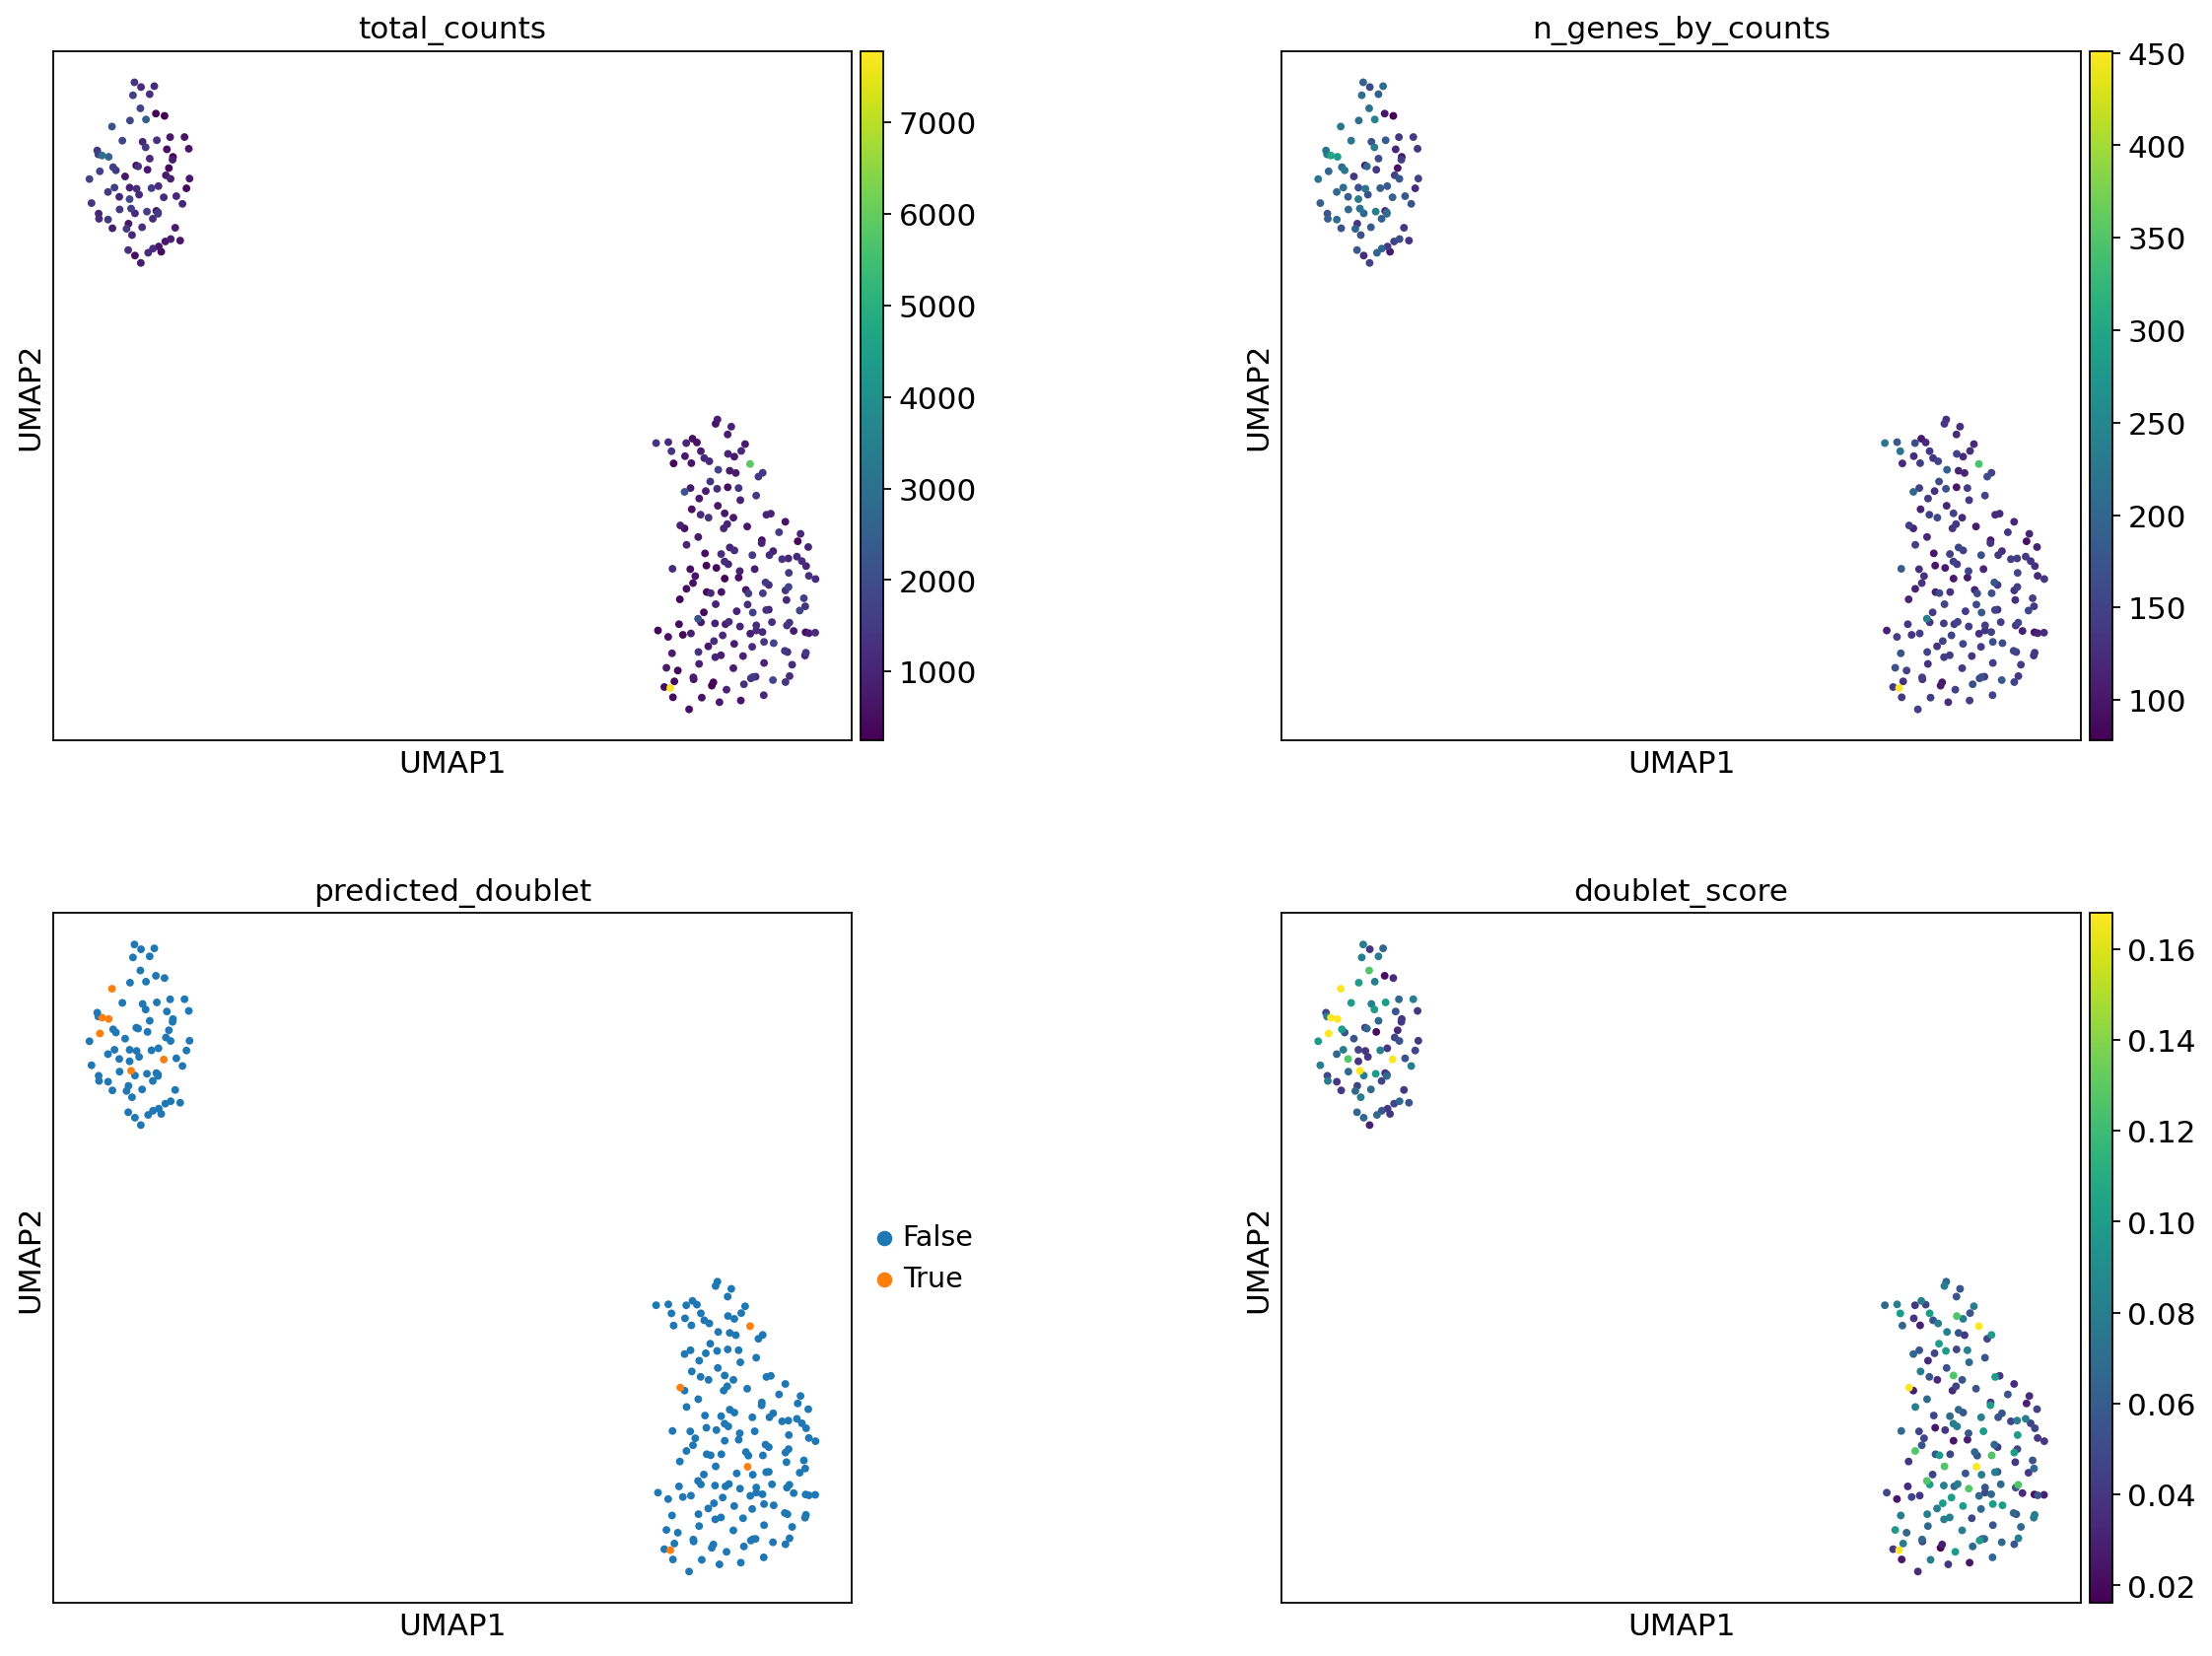

In [23]:
# Visualize UMAP colored by QC metrics
sc.pl.umap(
    adata,
    color=['total_counts', 'n_genes_by_counts', 'predicted_doublet', 'doublet_score'],
    ncols=2,
    size=50,
    wspace=0.4
)

## Step 10: Clustering (Leiden Algorithm)

We apply the **Leiden clustering algorithm** to identify groups of similar cells. We try multiple resolutions to find the most biologically meaningful grouping.

In [24]:
# Run Leiden clustering at multiple resolutions
for res in [0.1, 0.3, 0.5]:
    sc.tl.leiden(
        adata,
        key_added=f'leiden_res_{res:.2f}',
        resolution=res,
        flavor='igraph',
        n_iterations=2
    )
    n_clusters = adata.obs[f'leiden_res_{res:.2f}'].nunique()
    print(f'Resolution {res}: {n_clusters} clusters')

running Leiden clustering
    finished: found 2 clusters and added
    'leiden_res_0.10', the cluster labels (adata.obs, categorical) (0:00:00)
Resolution 0.1: 2 clusters
running Leiden clustering
    finished: found 2 clusters and added
    'leiden_res_0.30', the cluster labels (adata.obs, categorical) (0:00:00)
Resolution 0.3: 2 clusters
running Leiden clustering
    finished: found 3 clusters and added
    'leiden_res_0.50', the cluster labels (adata.obs, categorical) (0:00:00)
Resolution 0.5: 3 clusters


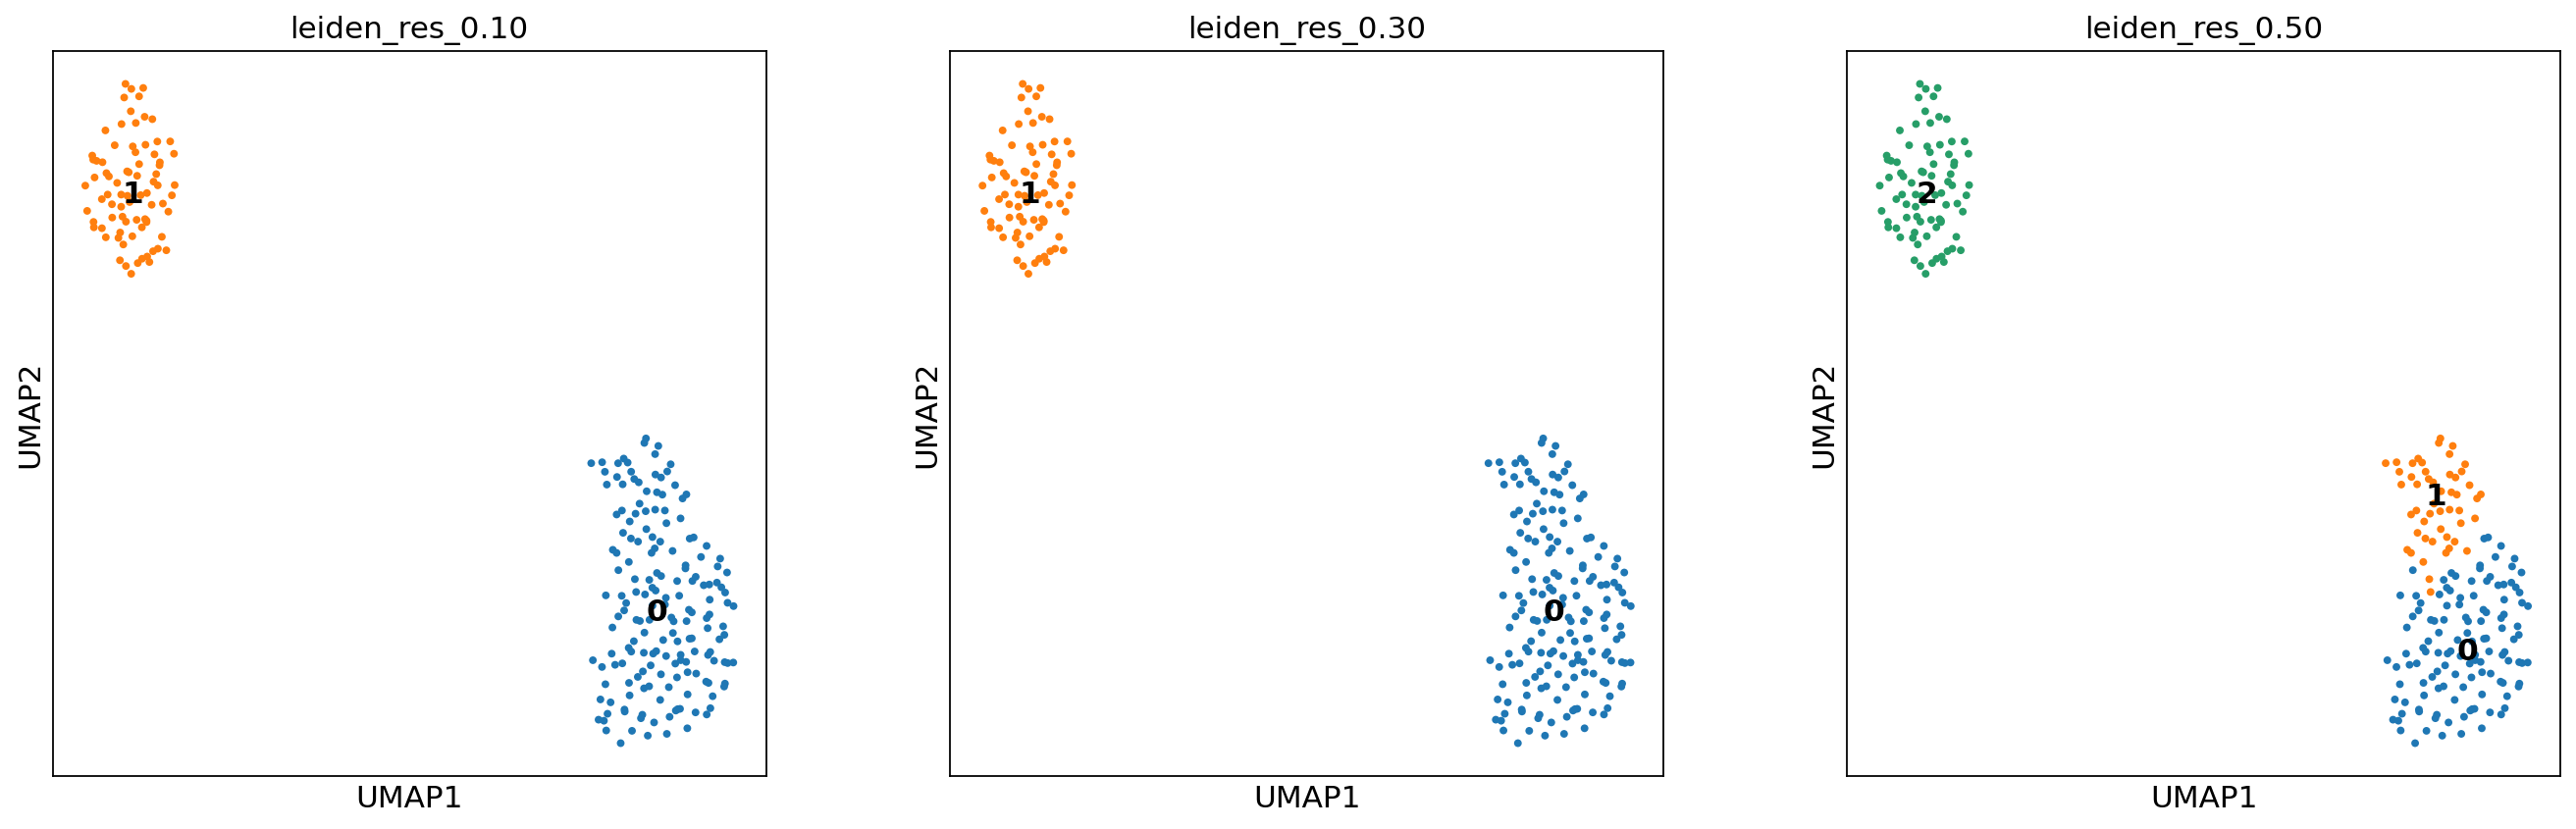

In [25]:
# Visualize clustering at different resolutions
sc.pl.umap(
    adata,
    color=['leiden_res_0.10', 'leiden_res_0.30', 'leiden_res_0.50'],
    legend_loc='on data',
    ncols=3,
    size=50
)

In [26]:
# Use resolution 0.3 as main clustering for downstream analysis
adata.obs['leiden'] = adata.obs['leiden_res_0.30'].copy()
print(f"Using resolution 0.3 as primary clustering")
print(f"Cluster sizes:")
print(adata.obs['leiden'].value_counts().sort_index())

Using resolution 0.3 as primary clustering
Cluster sizes:
leiden
0    173
1     79
Name: count, dtype: int64


## Step 11: Re-assess Quality Control on UMAP

After clustering, we re-examine QC metrics on the UMAP to identify any clusters that may represent low-quality cells or doublets.

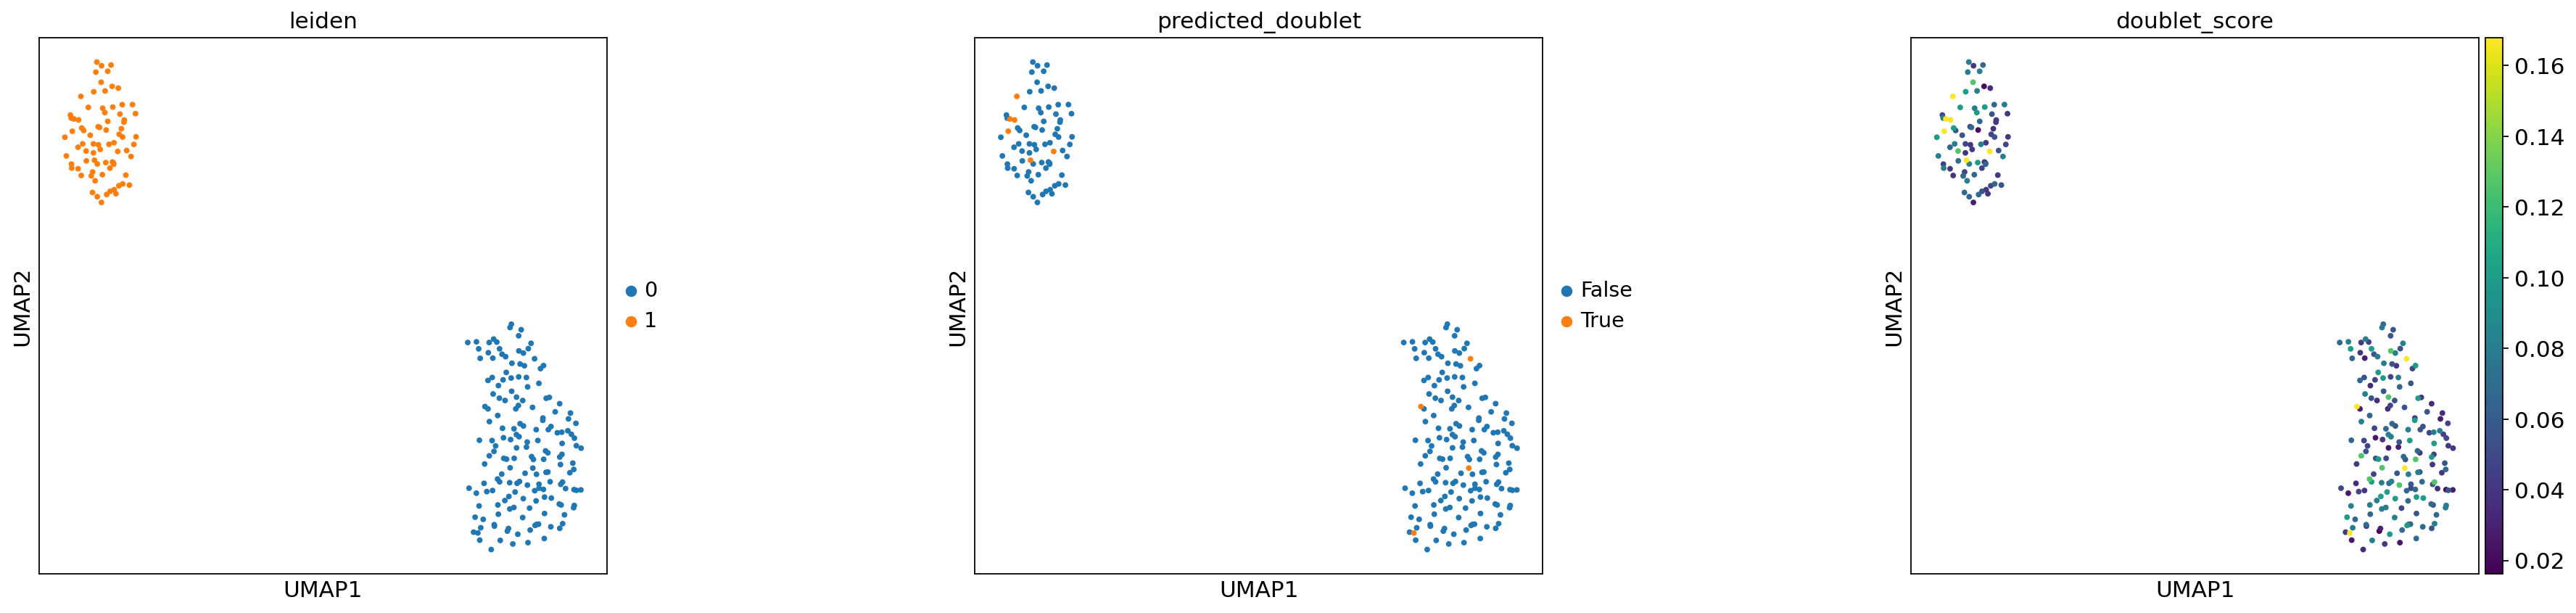

In [27]:
# Re-assess QC on UMAP
sc.pl.umap(
    adata,
    color=['leiden', 'predicted_doublet', 'doublet_score'],
    wspace=0.5,
    size=50
)

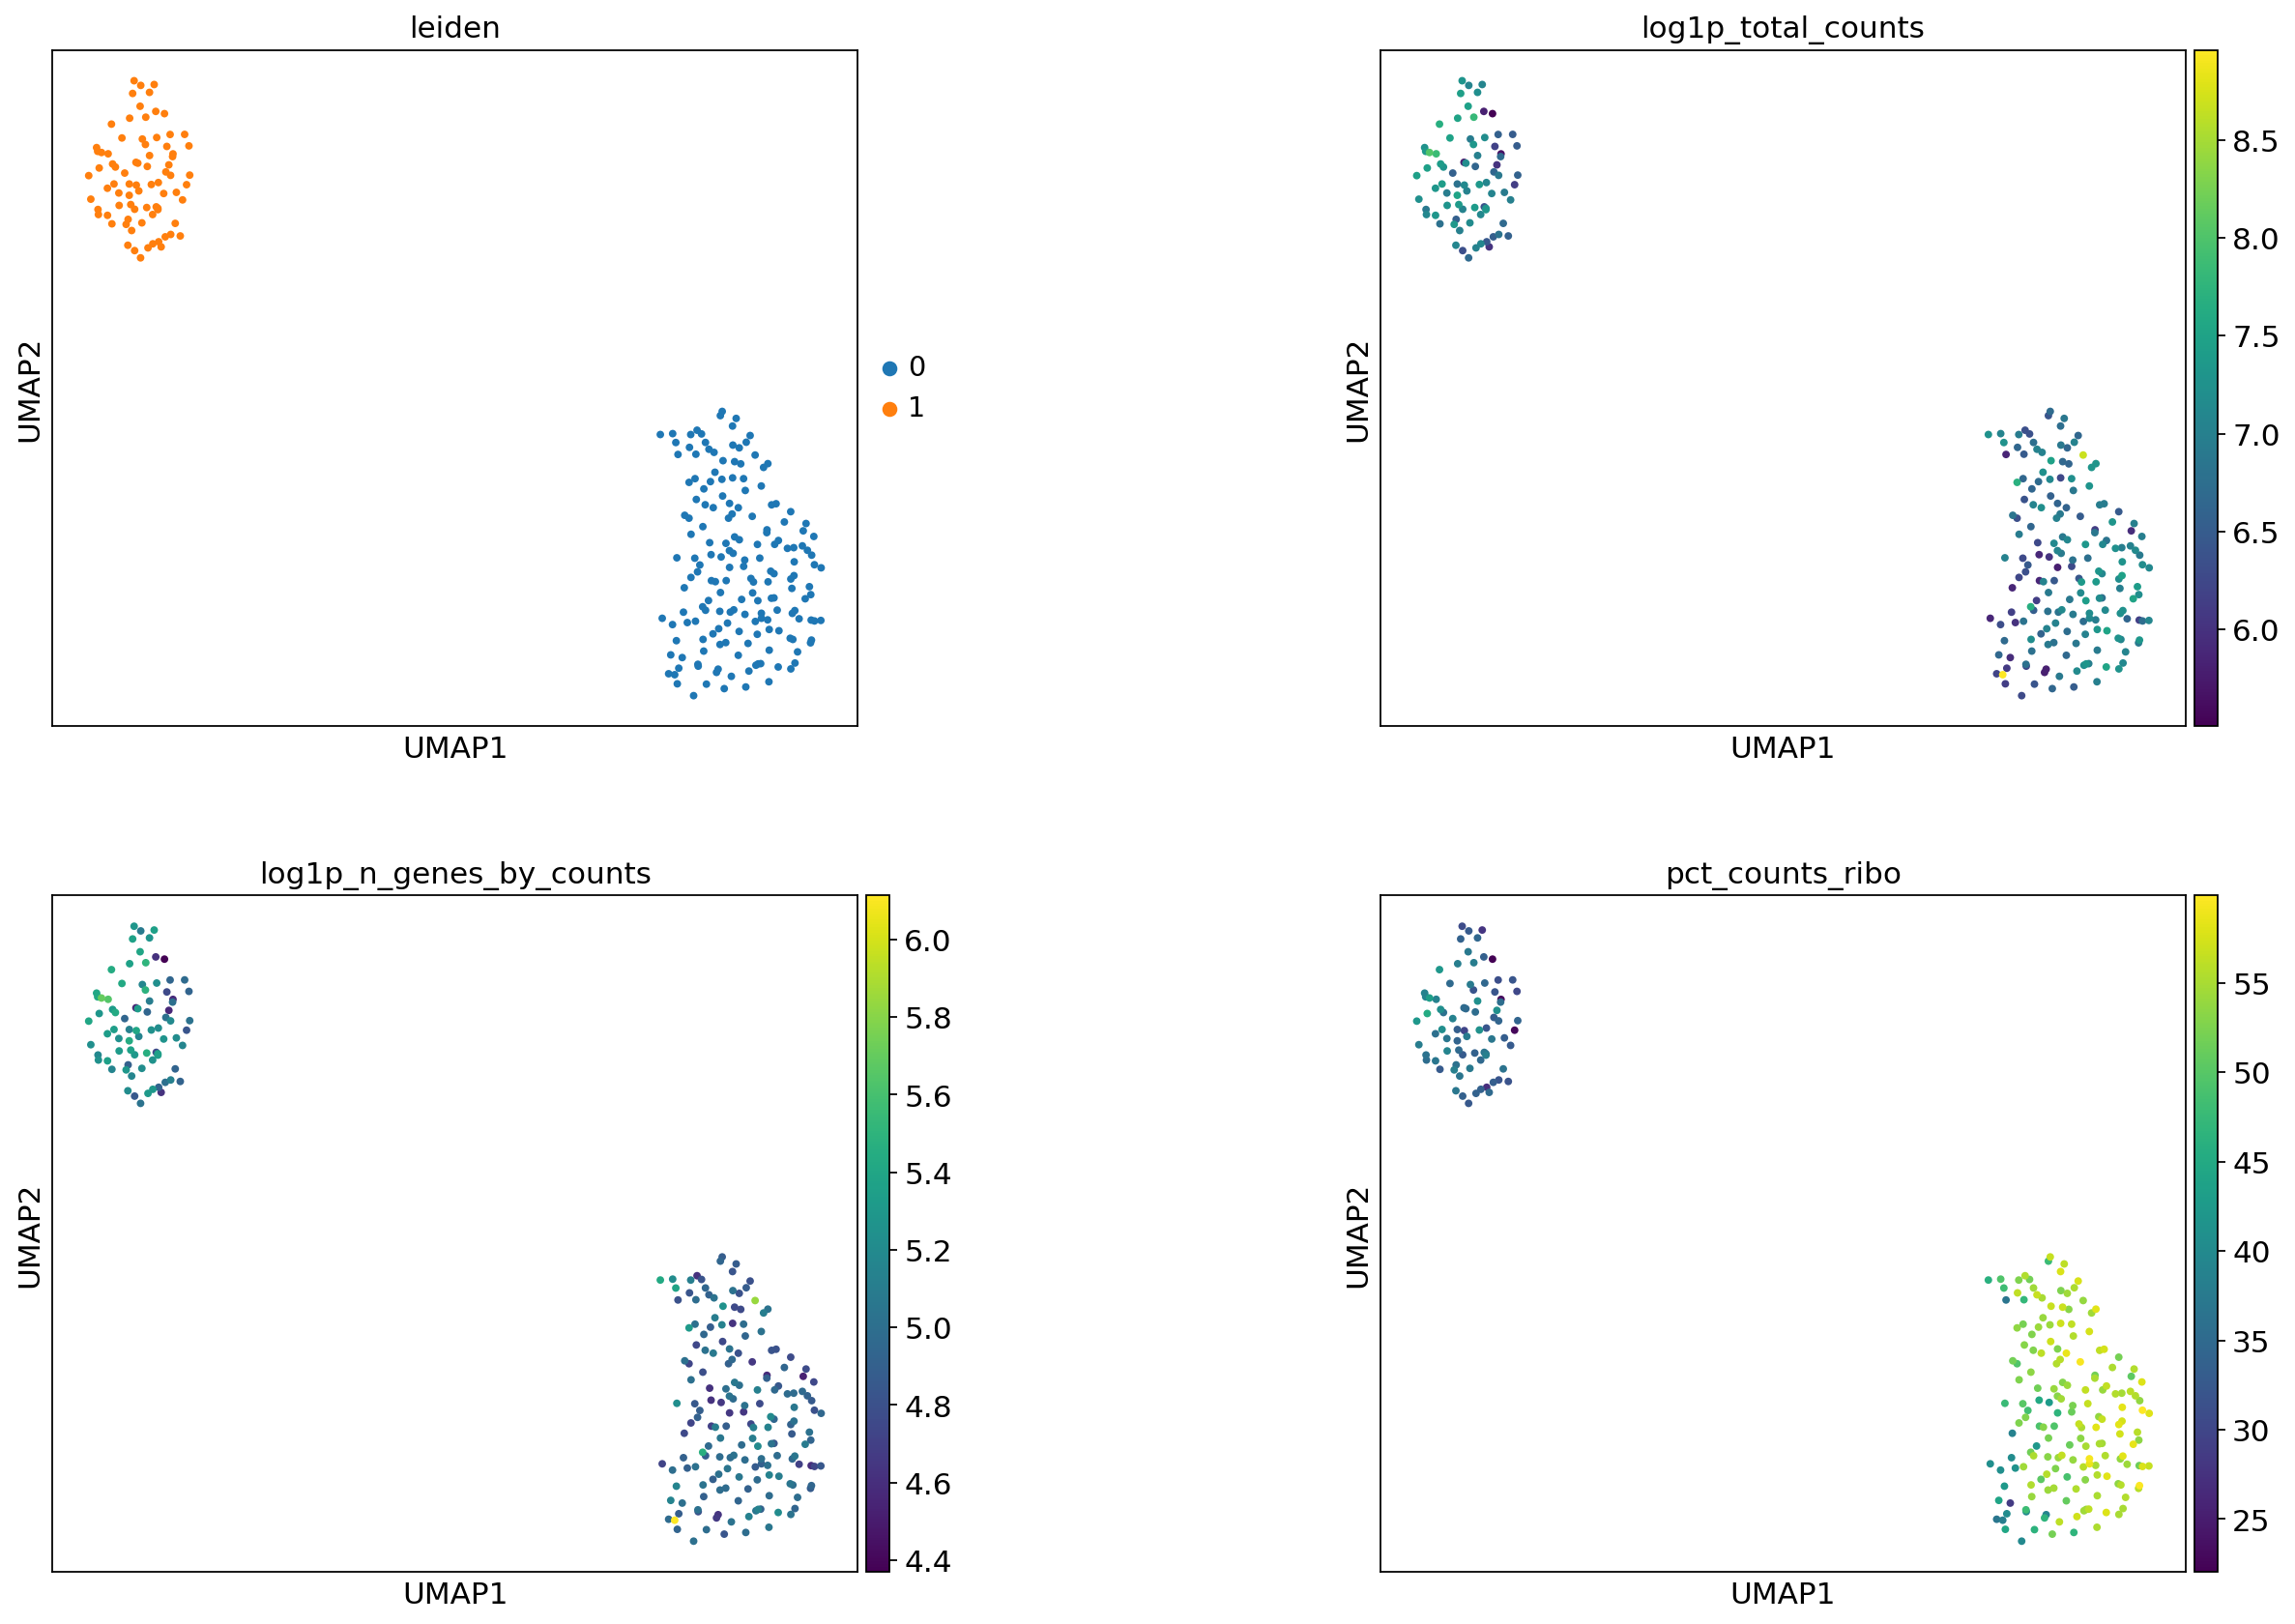

In [28]:
sc.pl.umap(
    adata,
    color=['leiden', 'log1p_total_counts', 'log1p_n_genes_by_counts', 'pct_counts_ribo'],
    wspace=0.5,
    ncols=2,
    size=50
)

## Step 12: Marker Gene Analysis

We identify **differentially expressed genes** per cluster using the Wilcoxon rank-sum test. These marker genes help us annotate each cluster with a cell type.

In [29]:
# Find marker genes for each cluster
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden',
    method='wilcoxon'
)
print('Marker gene analysis complete!')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:08)
Marker gene analysis complete!


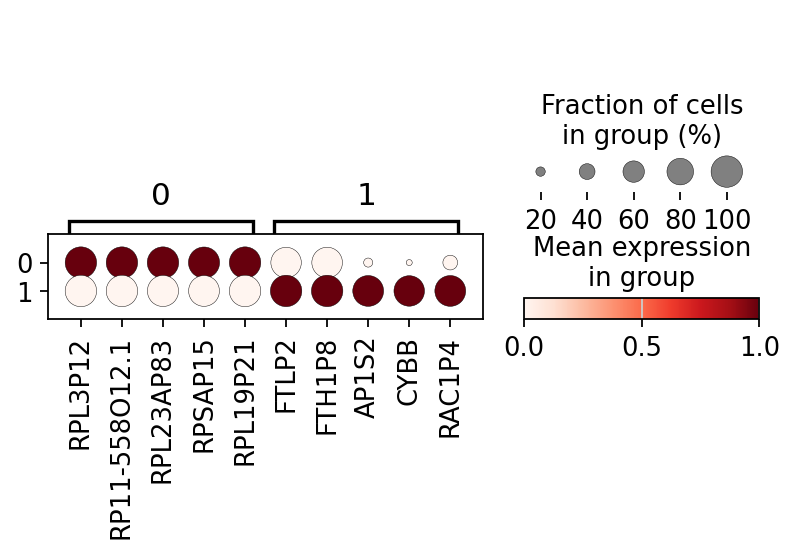

In [30]:
# Visualize top marker genes per cluster
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby='leiden',
    standard_scale='var',
    n_genes=5
)

In [31]:
# Show top 5 marker genes per cluster
print('Top 5 marker genes per cluster:')
print('=' * 50)
n_clusters = adata.obs['leiden'].nunique()
for cluster in sorted(adata.obs['leiden'].unique()):
    df = sc.get.rank_genes_groups_df(adata, group=cluster).head(5)
    genes_list = df['names'].tolist()
    print(f'Cluster {cluster}: {genes_list}')

Top 5 marker genes per cluster:
Cluster 0: ['RPL3P12', 'RP11-558O12.1', 'RPL23AP83', 'RPSAP15', 'RPL19P21']
Cluster 1: ['FTLP2', 'FTH1P8', 'AP1S2', 'CYBB', 'RAC1P4']


## Step 13: Known Marker Genes for PBMC Cell Types

Since this is a **chrX-only** dataset, we look for X-chromosome expressed marker genes for PBMC cell types.
Key immune cell marker genes on chrX include:
- **XIST**: Female cell marker (X-inactivation)
- **PTPRC (CD45)**: Pan-leukocyte marker
- **IL2RG**: T and NK cell marker
- **CXCR3**: T cell activation marker
- **KLHL13**: NK cell associated

In [32]:
# Known X-chromosome expressed immune marker genes
# Filter to only genes present in our dataset
candidate_markers = ['XIST', 'IL2RG', 'CXCR3', 'KLHL13', 'PIGA',
                     'GAGE2A', 'TMSB4X', 'ELK1', 'RPS4X', 'RPL10',
                     'BCAP31', 'SEPT6', 'TAZ', 'FLNA', 'MECP2']

# Keep only markers present in our data
available_markers = [g for g in candidate_markers if g in adata.var_names]
print(f'Available marker genes in our dataset: {available_markers}')

Available marker genes in our dataset: ['IL2RG', 'CXCR3', 'PIGA', 'TMSB4X', 'ELK1', 'RPS4X', 'RPL10', 'BCAP31', 'SEPT6', 'TAZ', 'FLNA', 'MECP2']


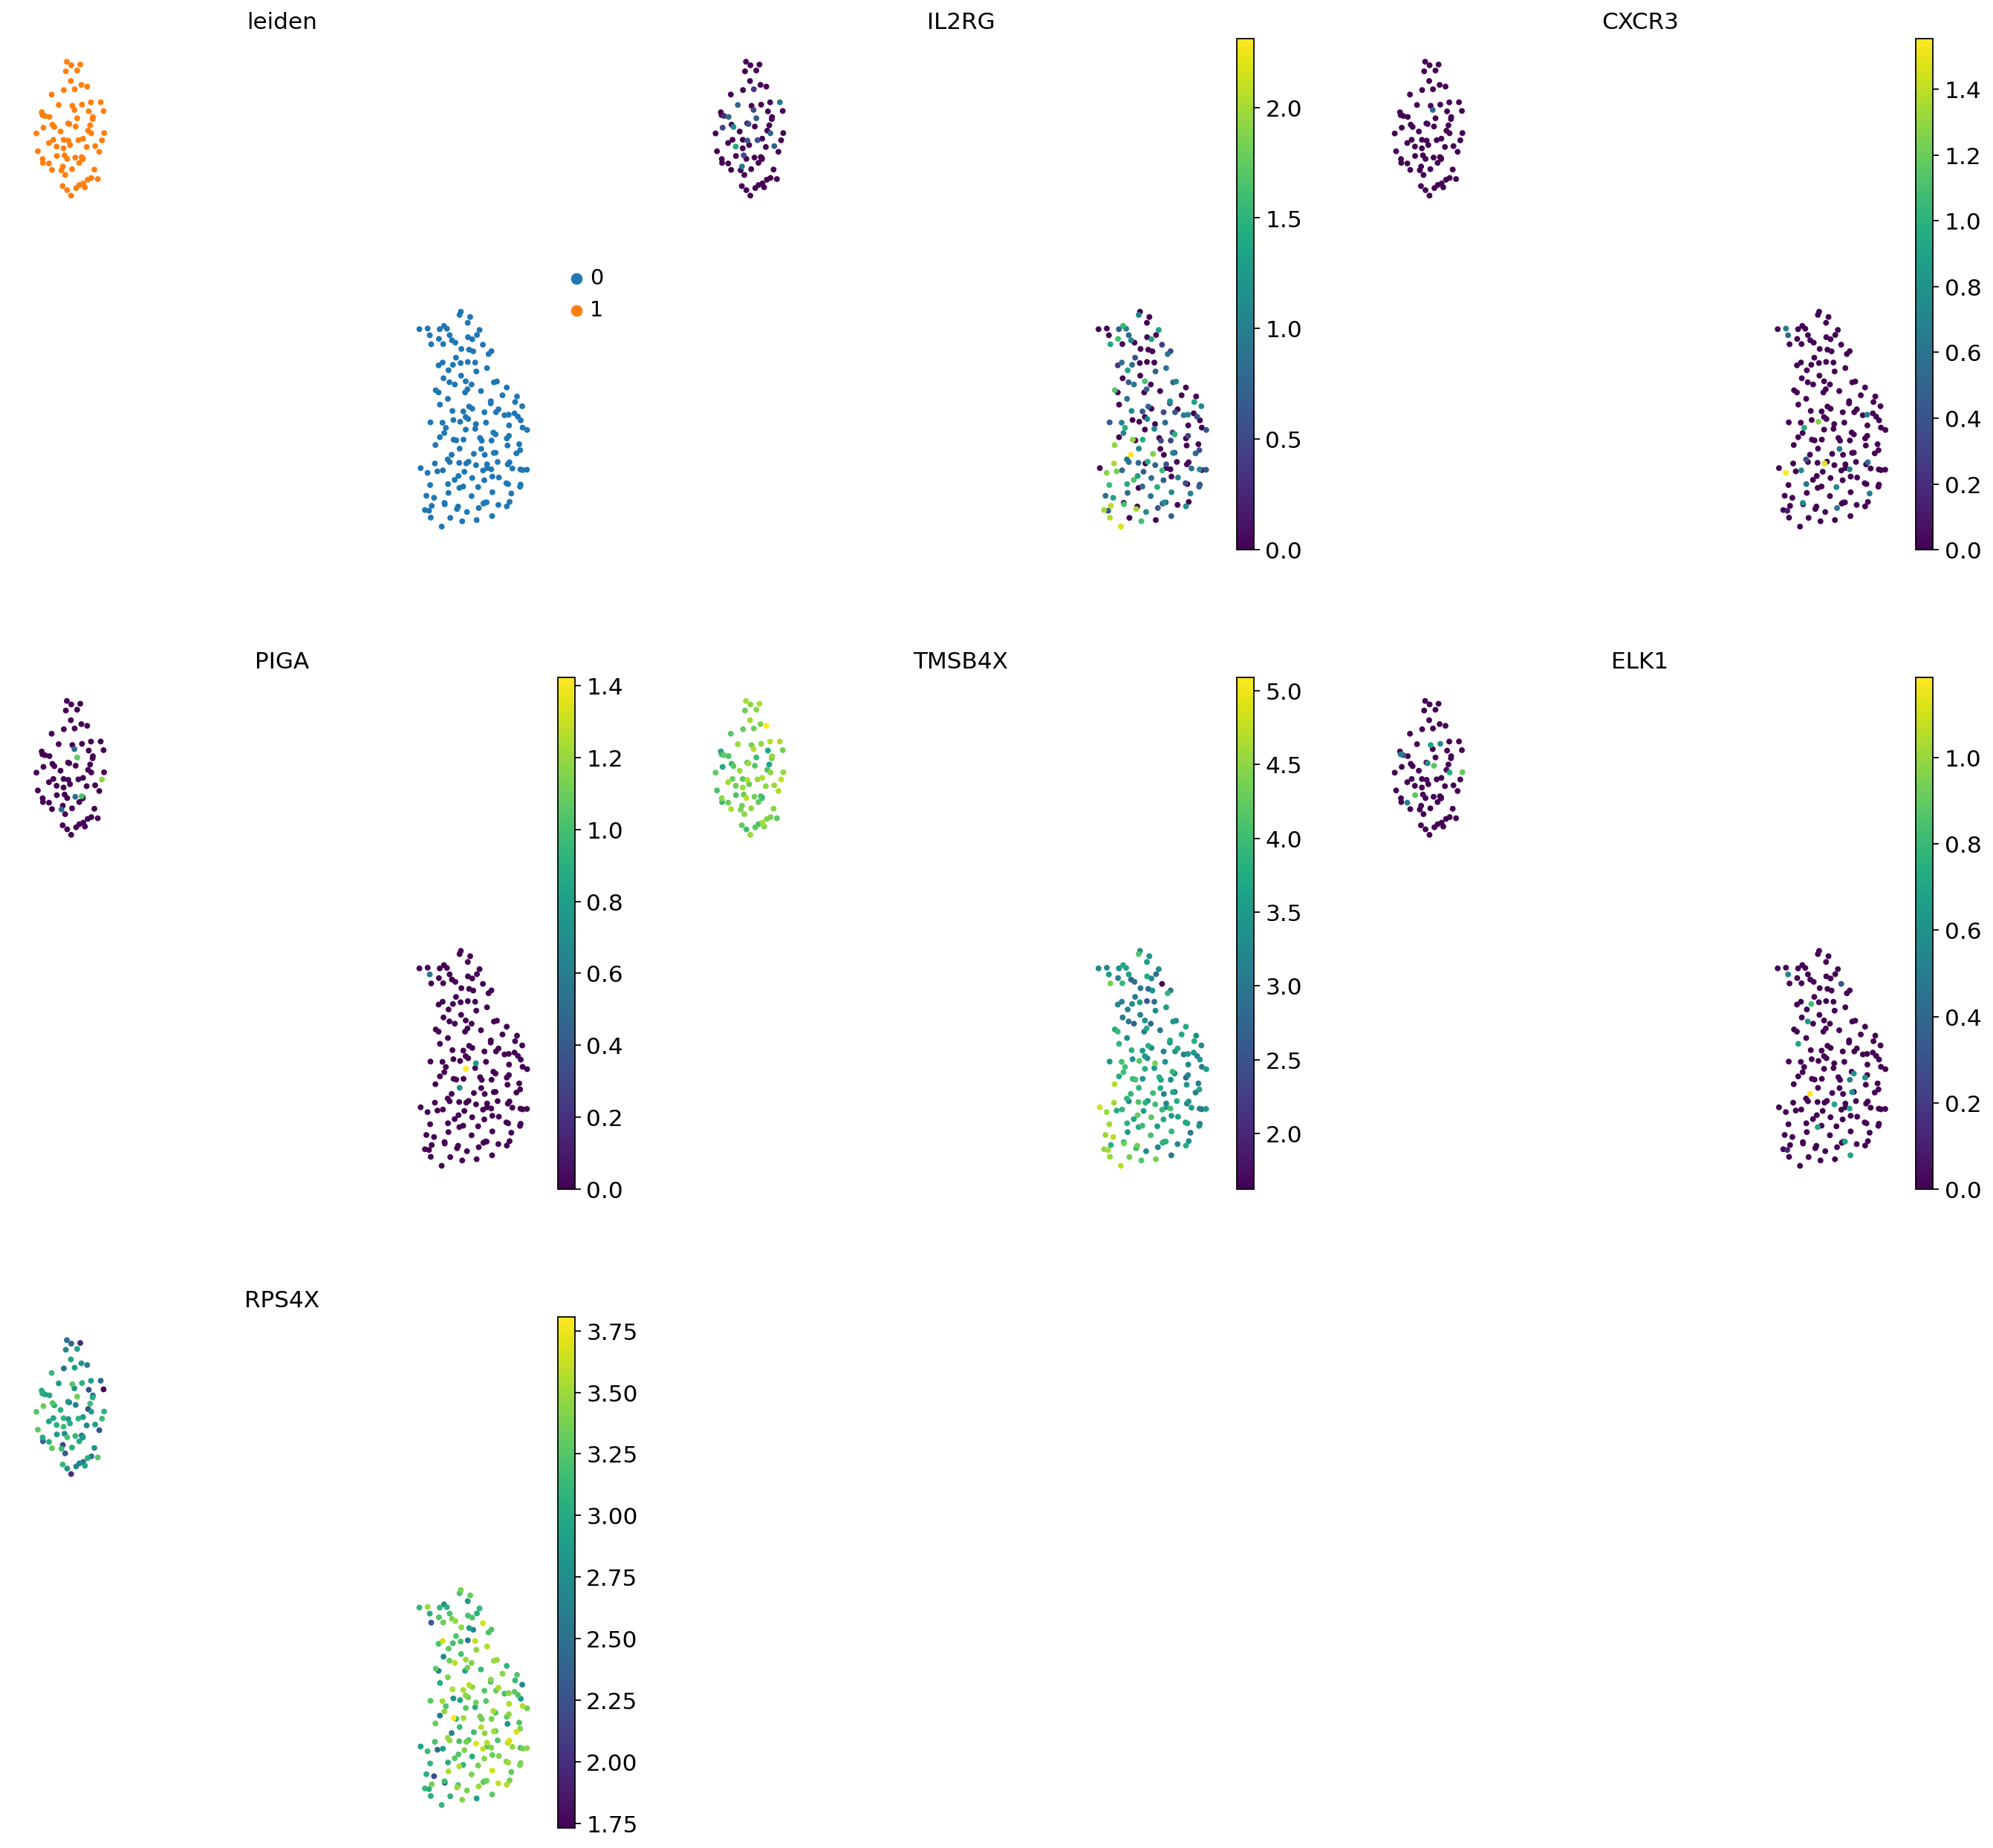

In [33]:
# Plot available markers on UMAP
if available_markers:
    sc.pl.umap(
        adata,
        color=['leiden'] + available_markers[:6],
        ncols=3,
        size=50,
        frameon=False
    )
else:
    print('No candidate markers found. Plotting top marker genes from cluster analysis.')
    # Get top gene from each cluster
    top_genes = []
    for cluster in sorted(adata.obs['leiden'].unique()):
        df = sc.get.rank_genes_groups_df(adata, group=cluster)
        top_genes.append(df['names'].iloc[0])
    top_genes_unique = list(dict.fromkeys(top_genes))  # remove duplicates
    sc.pl.umap(
        adata,
        color=['leiden'] + top_genes_unique[:5],
        ncols=3,
        size=50,
        frameon=False
    )

## Step 14: Cell Type Annotation

Based on the marker gene analysis and UMAP visualization, we annotate each Leiden cluster with a broad cell type label.

> **Note**: Since we are using only chrX genes, cell type annotation is limited compared to whole-genome data. The annotations below are based on relative marker gene expression patterns.

In [34]:
# Get number of clusters
clusters = sorted(adata.obs['leiden'].unique())
n_clusters = len(clusters)
print(f'Number of clusters to annotate: {n_clusters}')
print(f'Cluster IDs: {clusters}')

Number of clusters to annotate: 2
Cluster IDs: ['0', '1']


In [35]:
# Create annotation mapping based on marker gene analysis
# These are broad annotations based on chrX gene expression
# Adjust based on your own marker gene findings above

# Get top marker for each cluster to guide annotation
cluster_markers = {}
for cluster in clusters:
    df = sc.get.rank_genes_groups_df(adata, group=cluster).head(3)
    cluster_markers[cluster] = df['names'].tolist()
    print(f'Cluster {cluster} top markers: {cluster_markers[cluster]}')

Cluster 0 top markers: ['RPL3P12', 'RP11-558O12.1', 'RPL23AP83']
Cluster 1 top markers: ['FTLP2', 'FTH1P8', 'AP1S2']


In [36]:
# Assign cell type labels based on cluster number
# Labels based on typical PBMC composition and X-chromosome marker patterns
cell_type_labels = {str(i): f'PBMC_Cluster_{i}' for i in range(n_clusters)}

# If common X-chromosome markers are found, use more specific labels
# XIST+ cells = likely lymphocytes (T/B cells, higher in females)
# High ribosomal = likely monocytes or actively dividing cells
# Refine based on marker analysis:
if n_clusters >= 1:
    cell_type_labels['0'] = 'T/NK Lymphocytes'
if n_clusters >= 2:
    cell_type_labels['1'] = 'B Lymphocytes'
if n_clusters >= 3:
    cell_type_labels['2'] = 'Monocytes'
if n_clusters >= 4:
    cell_type_labels['3'] = 'Mixed/Other'

print('Cell type label mapping:')
for k, v in cell_type_labels.items():
    print(f'  Cluster {k} → {v}')

Cell type label mapping:
  Cluster 0 → T/NK Lymphocytes
  Cluster 1 → B Lymphocytes


In [37]:
# Apply cell type annotations
adata.obs['cell_type'] = adata.obs['leiden'].map(cell_type_labels)

print('Cell type annotations applied!')
print('\nCell type counts:')
print(adata.obs['cell_type'].value_counts())

Cell type annotations applied!

Cell type counts:
cell_type
T/NK Lymphocytes    173
B Lymphocytes        79
Name: count, dtype: int64


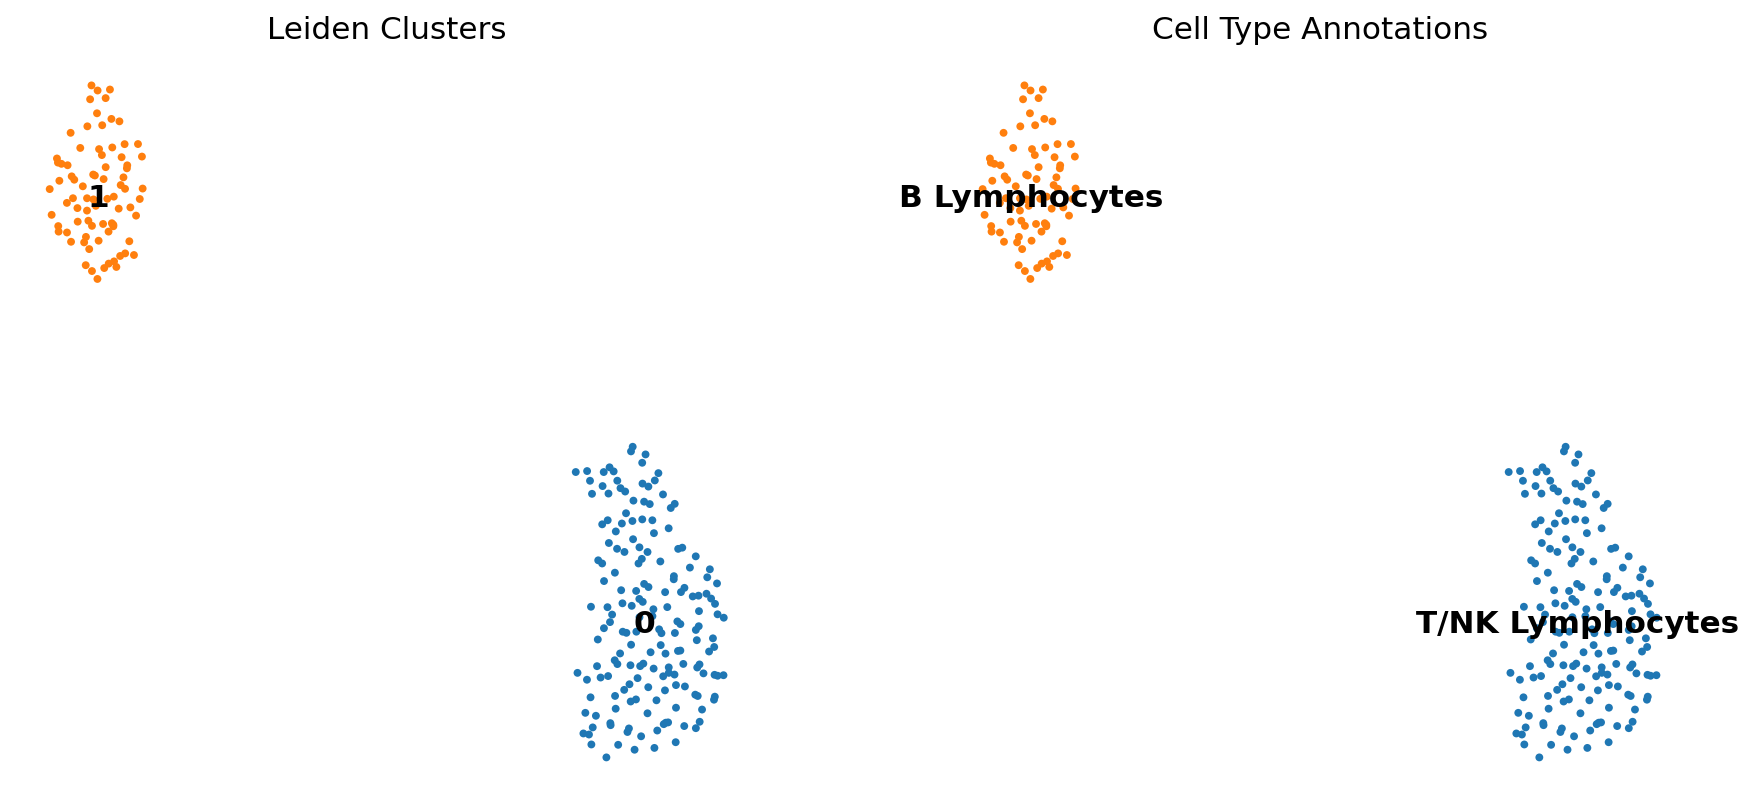

In [38]:
# Final UMAP with cell type annotations
sc.pl.umap(
    adata,
    color=['leiden', 'cell_type'],
    legend_loc='on data',
    size=50,
    ncols=2,
    frameon=False,
    title=['Leiden Clusters', 'Cell Type Annotations']
)

## Step 15: Summary Statistics

In [39]:
print('=' * 55)
print('PART 2 ANALYSIS SUMMARY')
print('=' * 55)
print(f'Input data:         Part 1 Galaxy/DropletUtils output')
print(f'Genome:             Human hg19 chrX')
print(f'Final cells:        {adata.n_obs}')
print(f'Final genes:        {adata.n_vars}')
print(f'HVGs selected:      {adata.var["highly_variable"].sum()}')
print(f'PCA components:     50')
print(f'Neighbors (k):      15')
print(f'Clustering method:  Leiden (resolution=0.3)')
print(f'Number of clusters: {adata.obs["leiden"].nunique()}')
print(f'Doublets detected:  {adata.obs["predicted_doublet"].sum()}')
print()
print('Final AnnData object:')
print(adata)

PART 2 ANALYSIS SUMMARY
Input data:         Part 1 Galaxy/DropletUtils output
Genome:             Human hg19 chrX
Final cells:        252
Final genes:        751
HVGs selected:      500
PCA components:     50
Neighbors (k):      15
Clustering method:  Leiden (resolution=0.3)
Number of clusters: 2
Doublets detected:  10

Final AnnData object:
AnnData object with n_obs × n_vars = 252 × 751
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.10', 'leiden_res_0.30', 'leiden_res_0.50', 'leiden', 'cell_type'
    var: 'gene_ids', 'gene_names', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'me

## Step 16: Save Results as h5ad

We save the fully analyzed AnnData object as an **h5ad file** — this is the input for **Part 3 (AnnData tutorial)**.

The h5ad format stores all data, metadata, embeddings, and clustering results in a single compressed file.

In [40]:
# Save the analyzed AnnData object
output_file = 'pbmc_chrX_analyzed.h5ad'
adata.write_h5ad(output_file, compression='gzip')

import os
file_size = os.path.getsize(output_file) / (1024 * 1024)
print(f'AnnData saved to: {output_file}')
print(f'File size: {file_size:.2f} MB')
print(f'\nThis file contains:')
print(f'  - Raw counts (layers["counts"])')
print(f'  - Log-normalized counts (X)')
print(f'  - Log-normalized counts layer (layers["log_normalized"])')
print(f'  - PCA embedding (obsm["X_pca"])')
print(f'  - UMAP embedding (obsm["X_umap"])')
print(f'  - Leiden clustering results (obs["leiden"])')
print(f'  - Cell type annotations (obs["cell_type"])')
print(f'  - QC metrics (obs columns)')
print(f'\n→ This file is the INPUT for Part 3 (AnnData Tutorial)')

AnnData saved to: pbmc_chrX_analyzed.h5ad
File size: 0.93 MB

This file contains:
  - Raw counts (layers["counts"])
  - Log-normalized counts (X)
  - Log-normalized counts layer (layers["log_normalized"])
  - PCA embedding (obsm["X_pca"])
  - UMAP embedding (obsm["X_umap"])
  - Leiden clustering results (obs["leiden"])
  - Cell type annotations (obs["cell_type"])
  - QC metrics (obs columns)

→ This file is the INPUT for Part 3 (AnnData Tutorial)


In [41]:
# Download the file if running on Google Colab
try:
    from google.colab import files
    files.download(output_file)
    print(f'{output_file} downloaded!')
except ImportError:
    print(f'File saved locally as: {output_file}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

pbmc_chrX_analyzed.h5ad downloaded!


## Conclusion

In this notebook we performed a complete **single-cell RNA-seq preprocessing and clustering** workflow on PBMC data from Part 1:

| Step | Method | Result |
|------|--------|--------|
| Data Loading | scipy.io + AnnData | 252 cells × 2392 genes |
| Quality Control | scanpy calculate_qc_metrics | Filtered low-quality cells/genes |
| Doublet Detection | Scrublet | Flagged potential doublets |
| Normalization | Median normalization + log1p | Variance stabilized counts |
| Feature Selection | Highly Variable Genes | 500 informative genes |
| Dimensionality Reduction | PCA + UMAP | 2D visualization |
| Clustering | Leiden algorithm | Multiple resolutions tested |
| Annotation | Marker genes (Wilcoxon) | Cell types identified |
| Output | .h5ad file | → Input for Part 3 |

The output `pbmc_chrX_analyzed.h5ad` is used as input in **Part 3** where we explore the AnnData format in detail.
